In [ ]:
import glob
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def load_data(index):

    folder_path = f"./output1/output_req{index}.json"
    
    # 自动去找里面的 part-00000-xxxx 文件
    files = glob.glob(folder_path + "/*part-*") 
    
    if not files:
        print(f"找不到需求 {index} 的数据文件，请检查路径！")
        return []
    
    data_list = []
    # 加上 encoding='utf-8' 防止 Windows 默认编码报错
    with open(files[0], 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data_list.append(json.loads(line))
    return data_list

print("准备工作完成！可以开始画图了。")

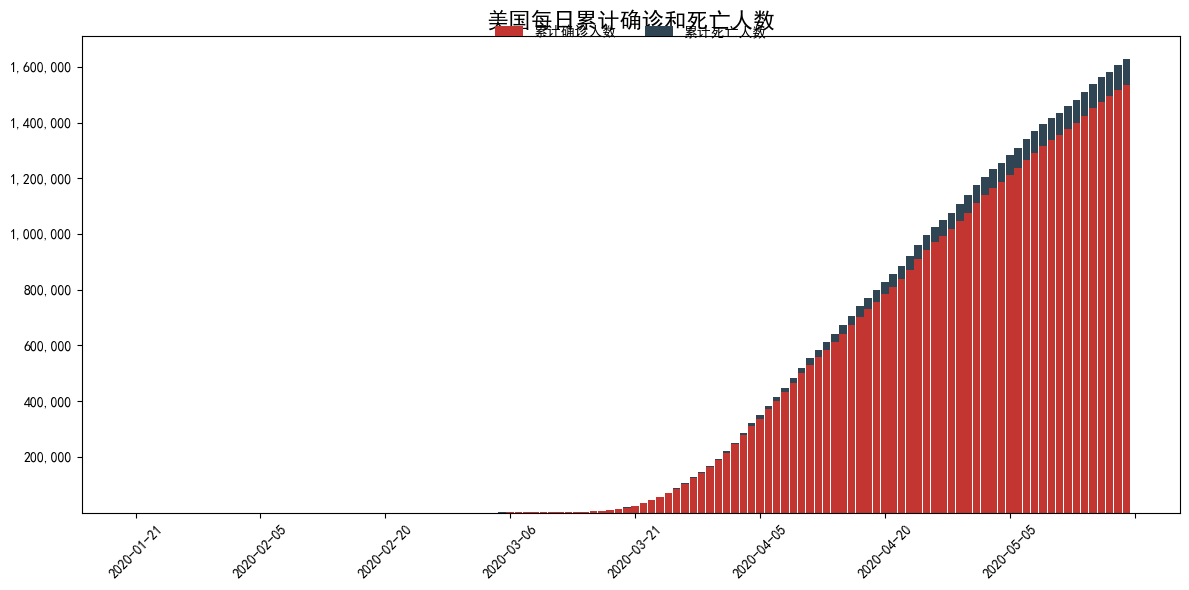

In [ ]:
data1 = load_data(1)
date1 = [str(js['date']) for js in data1]
cases1 = [int(js['cases']) for js in data1]
deaths1 = [int(js['deaths']) for js in data1]


x = np.arange(len(date1))  
width = 0.9 


plt.figure(figsize=(12, 6)) 


plt.bar(x, cases1, width, label="累计确诊人数", color="#c23531")

plt.bar(x, deaths1, width, bottom=cases1, label="累计死亡人数", color="#2f4554")

plt.xticks(x, date1, rotation=45)

plt.title("美国每日累计确诊和死亡人数", fontsize=16, fontweight='bold')


ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(15)) 


ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))


plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False)


plt.rcParams['font.sans-serif'] = ['SimHei'] 

plt.tight_layout()
plt.show()

In [ ]:

import os
import glob
import json
from pyecharts import options as opts
from pyecharts.charts import Bar, Line, Pie, Funnel, PictorialBar, WordCloud
from pyecharts.globals import SymbolType, ThemeType


BASE_PATH = "./output1"

def load_local_data(index):
    folder = os.path.join(BASE_PATH, f"output_req{index}.json")
    files = glob.glob(os.path.join(folder, "part-*"))
    if not files:
        print(f"找不到需求 {index} 的文件，请检查路径！")
        return []
    
    data = []
    with open(files[0], 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

print("本地数据读取函数准备就绪！")

本地数据读取函数准备就绪！


In [ ]:
#指向核心引擎，如果不成立则运行这个代码块
from pyecharts.globals import CurrentConfig, ThemeType, SymbolType
from pyecharts.charts import Bar, Line, Pie, Funnel, PictorialBar, WordCloud
import pyecharts.options as opts
import os, glob, json


CurrentConfig.ONLINE_HOST = "http://127.0.0.1:8000/"
BASE_PATH = "./output1"

def load_local_data(index):
    folder = os.path.join(BASE_PATH, f"output_req{index}.json")
    files = glob.glob(os.path.join(folder, "part-*"))
    if not files: return []
    data = []
    with open(files[0], 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): data.append(json.loads(line))
    return data

In [ ]:
from pyecharts.charts import Bar, Line
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
import os

from pyecharts.render import make_snapshot
from snapshot_selenium import snapshot 

CurrentConfig.ONLINE_HOST = "http://127.0.0.1:8000/"

res1 = load_local_data(1)
date1 = [str(js['date']) for js in res1]
cases1 = [int(js['cases']) for js in res1]
deaths1 = [int(js['deaths']) for js in res1]

bar1 = (
    Bar(init_opts=opts.InitOpts(theme=ThemeType.WONDERLAND, width="1100px", height="650px"))
    .add_xaxis(date1)
    .add_yaxis(
        "累计确诊人数", 
        cases1, 
        label_opts=opts.LabelOpts(is_show=False),
        color="#E66F6F",   
        category_gap="30%" 
    )
    .extend_axis(
        yaxis=opts.AxisOpts(
            name="死亡人数",
            type_="value",
            position="right",
            axisline_opts=opts.AxisLineOpts(linestyle_opts=opts.LineStyleOpts(color="#003366")),
            axislabel_opts=opts.LabelOpts(formatter="{value}人", color="#003366"),
        )
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="1. 美国每日疫情综合分析",
            subtitle="柱子代表确诊(左轴)，深蓝曲线代表死亡(右轴)",
            pos_left="center",  
            pos_top="2%",       
            title_textstyle_opts=opts.TextStyleOpts(font_size=20), 
        ),
        toolbox_opts=opts.ToolboxOpts(
            is_show=True, 
            pos_right="2%", 
            pos_top="2%"
        ),
        legend_opts=opts.LegendOpts(
            pos_top="12%", 
            pos_left="center"
        ),
        tooltip_opts=opts.TooltipOpts(trigger="axis", axis_pointer_type="cross"),
        datazoom_opts=[opts.DataZoomOpts(pos_bottom="5%")],
        yaxis_opts=opts.AxisOpts(
            name="确诊人数", 
            position="left",
            axislabel_opts=opts.LabelOpts(formatter="{value}人")
        ),
    )
)


line1 = (
    Line()
    .add_xaxis(date1)
    .add_yaxis(
        "累计死亡人数", 
        deaths1, 
        yaxis_index=1,
        color="#003366",   
        is_smooth=True,
        symbol_size=0,
        linestyle_opts=opts.LineStyleOpts(width=3), 
        label_opts=opts.LabelOpts(is_show=False),
        areastyle_opts=opts.AreaStyleOpts(opacity=0.4, color="#003366"),
    )
)


bar1.overlap(line1)


save_dir = "./final_html"
new_filename_pdf = "result_1.pdf"  
temp_html_name = "temp_result_1.html" 


if not os.path.exists(save_dir):
    os.makedirs(save_dir)

output_pdf = os.path.join(save_dir, new_filename_pdf)
temp_html = os.path.join(save_dir, temp_html_name)

print("正在调用无头浏览器渲染 PDF，请稍候...")

bar1.render(temp_html)
make_snapshot(snapshot, temp_html, output_pdf, is_remove_html=True) 

print(f"✅ 需求 1 图表已成功保存至: {output_pdf}")

In [ ]:
#最终版本第一幅图
from pyecharts.charts import Bar, Line
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
import os


CurrentConfig.ONLINE_HOST = "http://127.0.0.1:8000/"


res1 = load_local_data(1)
date1 = [str(js['date']) for js in res1]
cases1 = [int(js['cases']) for js in res1]
deaths1 = [int(js['deaths']) for js in res1]


bar1 = (
    Bar(init_opts=opts.InitOpts(theme=ThemeType.WONDERLAND, width="1100px", height="650px"))
    .add_xaxis(date1)
    .add_yaxis(
        "累计确诊人数", 
        cases1, 
        label_opts=opts.LabelOpts(is_show=False),
        color="#E66F6F",   
        category_gap="30%" 
    )
    .extend_axis(
        yaxis=opts.AxisOpts(
            name="死亡人数",
            type_="value",
            position="right",
            axisline_opts=opts.AxisLineOpts(linestyle_opts=opts.LineStyleOpts(color="#003366")),
            axislabel_opts=opts.LabelOpts(formatter="{value}人", color="#003366"),
        )
    )
    .set_global_opts(

        title_opts=opts.TitleOpts(
            title="1. 美国每日疫情综合分析",
            subtitle="柱子代表确诊(左轴)，深蓝曲线代表死亡(右轴)",
            pos_left="center",  
            pos_top="2%",       
            title_textstyle_opts=opts.TextStyleOpts(font_size=20), 
        ),
        
        toolbox_opts=opts.ToolboxOpts(
            is_show=True, 
            pos_right="2%", 
            pos_top="2%"
        ),
        

        legend_opts=opts.LegendOpts(
            pos_top="12%", 
            pos_left="center"
        ),
        
        tooltip_opts=opts.TooltipOpts(trigger="axis", axis_pointer_type="cross"),
        datazoom_opts=[opts.DataZoomOpts(pos_bottom="5%")],
        yaxis_opts=opts.AxisOpts(
            name="确诊人数", 
            position="left",
            axislabel_opts=opts.LabelOpts(formatter="{value}人")
        ),
    )
)


line1 = (
    Line()
    .add_xaxis(date1)
    .add_yaxis(
        "累计死亡人数", 
        deaths1, 
        yaxis_index=1,
        color="#003366",   
        is_smooth=True,
        symbol_size=0,
        linestyle_opts=opts.LineStyleOpts(width=3), 
        label_opts=opts.LabelOpts(is_show=False),
        areastyle_opts=opts.AreaStyleOpts(opacity=0.4, color="#003366"),
    )
)

bar1.overlap(line1)


save_dir = "./final_html"
new_filename = "result_1.html"  

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

output_file_1 = os.path.join(save_dir, new_filename)
bar1.render(output_file_1)

print(f"✅ 需求 1 图表已成功保存至: {output_file_1}")

In [ ]:
#最终版本第二幅图
from pyecharts.globals import CurrentConfig, ThemeType
from pyecharts.charts import Line
import pyecharts.options as opts
import os


CurrentConfig.ONLINE_HOST = "http://127.0.0.1:8000/"


res2 = load_local_data(2)
date2 = [str(js['date']) for js in res2]
c_inc = [int(js['case_increase']) for js in res2]
d_inc = [int(js['death_increase']) for js in res2]


line2 = (
    Line(init_opts=opts.InitOpts(
        theme=ThemeType.WONDERLAND, 
        width="1100px", 
        height="600px"
    ))
    .add_xaxis(date2)

    .add_yaxis(
        "每日新增确诊", 
        c_inc, 
        is_smooth=True, 
        symbol_size=8,

        markpoint_opts=opts.MarkPointOpts(data=[opts.MarkPointItem(type_="max", name="峰值")]),
        markline_opts=opts.MarkLineOpts(data=[opts.MarkLineItem(type_="average", name="平均水平")]),

        areastyle_opts=opts.AreaStyleOpts(opacity=0.3),
        label_opts=opts.LabelOpts(is_show=False)
    )

    .add_yaxis(
        "每日新增死亡", 
        d_inc, 
        is_smooth=True, 
        symbol_size=8,

        markpoint_opts=opts.MarkPointOpts(data=[opts.MarkPointItem(type_="max", name="峰值")]),
        markline_opts=opts.MarkLineOpts(data=[opts.MarkLineItem(type_="average", name="平均水平")]),
        areastyle_opts=opts.AreaStyleOpts(opacity=0.2),
        label_opts=opts.LabelOpts(is_show=False)
    )
    .set_global_opts(

        title_opts=opts.TitleOpts(
            title="2. 美国每日新增确诊与死亡趋势分析",
            subtitle="虚线代表平均新增水平",
            pos_left="center",
            pos_top="2%"
        ),
        legend_opts=opts.LegendOpts(pos_top="10%", pos_left="center"),
        toolbox_opts=opts.ToolboxOpts(is_show=True, pos_right="2%", pos_top="2%"),
        datazoom_opts=[opts.DataZoomOpts(pos_bottom="5%")],
        tooltip_opts=opts.TooltipOpts(trigger="axis", axis_pointer_type="line"),
        xaxis_opts=opts.AxisOpts(boundary_gap=False) 
)
)

save_dir = "./final_html"
new_filename = "result_2.html"  

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

output_file_2 = os.path.join(save_dir, new_filename)
line2.render(output_file_2)

print(f"✅ 需求 2 图表已成功保存至: {output_file_2}")

In [ ]:
#最终版本第三幅图
from pyecharts import options as opts
from pyecharts.charts import Map
from pyecharts.globals import CurrentConfig
import os
import json 


CurrentConfig.ONLINE_HOST = "https://cdn.jsdelivr.net/gh/pyecharts/pyecharts-assets@master/assets/"
save_dir = "./final_html"
if not os.path.exists(BASE_PATH):
    os.makedirs(BASE_PATH)


try:
    res3 = load_local_data(3)
except NameError:
    print("函数 load_local_data 未定义！请先运行包含该函数的单元格。")
    res3 = []

if not res3:
    print("未能获取到有效数据 (res3 为空)。请检查数据源文件是否存在！")
else:

    tasks = [
        {
            "key": "total_cases", 
            "name": "累计确诊人数", 
            "suffix": "cases",
            "unit": "w", 
            "divisor": 10000,
            "pieces": [
                {"max": 30000, "label": "<3w", "color": "#fef08a"},
                {"min": 30001, "max": 60000, "label": "3w-6w", "color": "#fbbf24"},
                {"min": 60001, "max": 100000, "label": "6w-10w", "color": "#f97316"},
                {"min": 100001, "max": 200000, "label": "10w-20w", "color": "#ef4444"},
                {"min": 200001, "label": ">20w", "color": "#991b1b"}
            ]
        },
        {
            "key": "total_deaths", 
            "name": "累计死亡人数", 
            "suffix": "deaths",
            "unit": "人", 
            "divisor": 1,
            "pieces": [
                {"max": 1000, "label": "<1k", "color": "#fef08a"},
                {"min": 1001, "max": 5000, "label": "1k-5k", "color": "#fbbf24"},
                {"min": 5001, "max": 10000, "label": "5k-10k", "color": "#f97316"},
                {"min": 10001, "max": 20000, "label": "10k-20k", "color": "#ef4444"},
                {"min": 20001, "label": ">20k", "color": "#991b1b"}
            ]
        },
        {
            "key": "death_rate", 
            "name": "死亡率", 
            "suffix": "rate",
            "unit": "%", 
            "divisor": 0.01, 
            "pieces": [
                {"max": 0.03, "label": "<3%", "color": "#fef08a"},
                {"min": 0.0301, "max": 0.05, "label": "3%-5%", "color": "#fbbf24"},
                {"min": 0.0501, "max": 0.07, "label": "5%-7%", "color": "#f97316"},
                {"min": 0.0701, "max": 0.09, "label": "7%-9%", "color": "#ef4444"},
                {"min": 0.0901, "label": ">9%", "color": "#991b1b"}
            ]
        }
    ]

    print(f"📊 正在批量生成疫情数据分析图表...")

    for task in tasks:
        data_pair = []
        for js in res3:
            state = js.get('state', 'Unknown').strip()

            val = js.get(task['key'], 0) 
            data_pair.append((state, val))
        

        if not data_pair:
             print(f"⚠️ 警告：无法解析出 '{task['name']}' 的有效数据，跳过绘图。")
             continue
        

        top5_data = sorted(data_pair, key=lambda x: x[1], reverse=True)[:5]
        top5_text = f"🏆 {task['name']} Top 5\n\n"
        for i, (name, val) in enumerate(top5_data):
            display_val = round(val / task['divisor'], 2)
            top5_text += f"{i+1}. {name}: {display_val}{task['unit']}\n\n"


        c = (
            Map()
            .add(series_name=task['name'], data_pair=data_pair, maptype="美国", is_roam=True,
                 pos_left="0%", label_opts=opts.LabelOpts(is_show=False))
            .set_global_opts(
                title_opts=opts.TitleOpts(title=f"3. 美国各州疫情分布 - {task['name']}", pos_left="left", pos_top="10px"),
                visualmap_opts=opts.VisualMapOpts(is_piecewise=True, pos_left="10px", pos_bottom="10px", pieces=task['pieces']),
                tooltip_opts=opts.TooltipOpts(is_show=True, trigger="item", 
                                              formatter=f"{{b}}<br/>{task['name']}: {{c}}" + (task['unit'] if task['unit']=='%' else "")),
                graphic_opts=[opts.GraphicGroup(
                    graphic_item=opts.GraphicItem(right="5", top="30%"),
                    children=[opts.GraphicText(graphic_textstyle_opts=opts.GraphicTextStyleOpts(
                        text=top5_text, font="bold 13px Microsoft YaHei"))]
                )]
            )
        )
        
        filename = f"result_3_map_{task['suffix']}.html"
        output_path = os.path.join(save_dir, filename)
        c.render(output_path)
        
        preview_url = f"http://127.0.0.1:8000/{filename}"
        print(f"✅ {task['name']} 地图已生成，点击预览: {preview_url}")

In [ ]:
#最终版本第四幅图
from pyecharts.globals import CurrentConfig, ThemeType
from pyecharts.charts import Bar
import pyecharts.options as opts
import os


CurrentConfig.ONLINE_HOST = "http://127.0.0.1:8000/"


res4 = load_local_data(4)
res4 = [js for js in res4 if js.get('state') != 'USA']
res4.sort(key=lambda x: x.get('total_cases', x.get('totalCases', 0)))
top10_cases = res4[-10:] 

states4 = [str(js['state']) for js in top10_cases]
cases4 = [int(js.get('total_cases', js.get('totalCases', 0))) for js in top10_cases]

max_cases = max(cases4) if cases4 else 1000000
min_cases = min(cases4) if cases4 else 0


bar4_final = (
    Bar(init_opts=opts.InitOpts(
        theme=ThemeType.LIGHT,
        bg_color="#f4f7f7", 
        width="1000px", 
        height="600px"
    ))
    .add_xaxis(states4)
    .add_yaxis(
        series_name="确诊人数", 
        y_axis=cases4, 
        itemstyle_opts=opts.ItemStyleOpts(
            border_radius=[0, 15, 15, 0], 
            color="#3498DB" 
        ),
        label_opts=opts.LabelOpts(
            position="right", 
            formatter="{c} 人",
            color="#333", 
            font_weight="bold"
        ) 
    )
    .reversal_axis() 
    .set_global_opts(

        title_opts=opts.TitleOpts(
            title="4. 美国各州累计确诊人数 Top 10", 
            subtitle="颜色代表确诊规模",
            pos_top="2%",   
            pos_left="5%",  
            title_textstyle_opts=opts.TextStyleOpts(color="#003366", font_size=20)
        ),
        

        toolbox_opts=opts.ToolboxOpts(is_show=True),
        
        xaxis_opts=opts.AxisOpts(is_show=False), 
        yaxis_opts=opts.AxisOpts(
            axislabel_opts=opts.LabelOpts(color="#333", font_size=12),
            axisline_opts=opts.AxisLineOpts(is_show=False),
            axistick_opts=opts.AxisTickOpts(is_show=False)
        ),
        

        visualmap_opts=opts.VisualMapOpts(
            is_show=True,
            max_=max_cases,
            min_=min_cases,   
            dimension=0,      
            orient="horizontal", 
            pos_left="center",
            pos_bottom="5%",
            range_color=["#87CEFA", "#3498DB", "#003366"] 
        )
    )
)

save_dir = "./final_html"
new_filename = "result_4.html"  

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

output_file_4 = os.path.join(save_dir, new_filename)
bar4_final.render(output_file_4)

print(f"✅ 需求 4 图表已成功保存至: {output_file_4}")

In [ ]:
#最终版本第五幅图
from pyecharts.globals import CurrentConfig, ThemeType
from pyecharts.charts import Bar
import pyecharts.options as opts
import os


res5 = load_local_data(5)


res5 = [js for js in res5 if js.get('state') != 'USA']


res5.sort(key=lambda x: x.get('total_deaths', x.get('totalDeaths', 0)))
top10_data = res5[-10:] 

states5 = [str(js['state']) for js in top10_data]
deaths5 = [int(js.get('total_deaths', js.get('totalDeaths', 0))) for js in top10_data]


max_death = max(deaths5) if deaths5 else 100000
min_death = min(deaths5) if deaths5 else 0


bar5_unique = (
    Bar(init_opts=opts.InitOpts(
        theme=ThemeType.DARK, 
        width="1000px", 
        height="600px"
    ))
    .add_xaxis(states5)
    .add_yaxis(
        series_name="死亡人数", 
        y_axis=deaths5, 
        label_opts=opts.LabelOpts(position="right", formatter="{c} 人") 
    )
    .reversal_axis() 
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="5. 美国各州死亡人数 Top 10", 
            subtitle="颜色深度代表疫情严重程度",
            pos_top="2%",   
            pos_left="5%"   
        ),
        toolbox_opts=opts.ToolboxOpts(is_show=True),
        xaxis_opts=opts.AxisOpts(is_show=False), 
        
            visualmap_opts=opts.VisualMapOpts(
            is_show=True,
            max_=max_death,
            min_=min_death,   
            dimension=0,      
            orient="horizontal", 
            pos_left="center",
            pos_bottom="5%",
            range_color=["#FFD700", "#FF8C00", "#FF0000"] 
        )
    )
)



save_dir = "./final_html"
new_filename = "result_5.html" 

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

output_file_5 = os.path.join(save_dir, new_filename)
bar5_unique.render(output_file_5)

print(f"✅ 需求 5 图表已成功保存至: {output_file_5}")

In [ ]:
#最终版本第六幅图
from pyecharts.globals import CurrentConfig, ThemeType
from pyecharts.charts import Pie
import pyecharts.options as opts
import os


CurrentConfig.ONLINE_HOST = "http://127.0.0.1:8000/"


res8 = load_local_data(8)
data8 = []
for js in res8:
    if js.get('state') == "USA":
        rate = round(float(js.get('death_rate', js.get('deathRate', 0))) * 100, 2)
        data8 = [("累计病死率", rate), ("生存/非病死率", round(100 - rate, 2))]
        break


pie8 = (

    Pie(init_opts=opts.InitOpts(
        theme=ThemeType.MACARONS, 
        width="1000px", 
        height="600px"
    ))
    .add(
        series_name="全美病死率统计",
        data_pair=data8,
        radius=["45%", "75%"],      
        itemstyle_opts=opts.ItemStyleOpts(
            border_radius=10,       
            border_color="#fff", 
            border_width=2
        )
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="6. 全美总体病死率占比分析",
            pos_left="2%",
            pos_top="2%"
        ),
        legend_opts=opts.LegendOpts(
            orient="vertical",
            pos_left="2%",
            pos_top="15%" 
        ),

        toolbox_opts=opts.ToolboxOpts(
            is_show=True,
            pos_right="2%",
            pos_top="2%"
        )
    )
    .set_series_opts(
        label_opts=opts.LabelOpts(
            is_show=True, 
            formatter="{b}: {c}%",
            font_size=14
        )
    )
)


save_dir = "./final_html"
new_filename = "result_6.html"  

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

output_file_6 = os.path.join(save_dir, new_filename)
pie8.render(output_file_6)

print(f"✅ 需求 6 图表已成功保存至: {output_file_6}")

In [ ]:
#最终版本第七幅图
from pyecharts import options as opts
from pyecharts.charts import Bar
from pyecharts.globals import ThemeType, CurrentConfig
import os

CurrentConfig.ONLINE_HOST = "https://cdn.jsdelivr.net/gh/pyecharts/pyecharts-assets@master/assets/"

save_dir = "./final_html"

res9 = load_local_data(9)
if not res9:
    print("没读到数据，请检查 G 盘路径！")
else:
    latest_date = max([js['date'] for js in res9])
    current_res9 = [js for js in res9 if js['date'] == latest_date]


    clean_dict = {}
    for js in current_res9:
        state_name = str(js['state']).strip() 
        val = float(js.get('rolling_avg', 0))
        clean_dict[state_name] = clean_dict.get(state_name, 0) + val

    data_pair_9 = sorted([(k, v) for k, v in clean_dict.items()], key=lambda x: x[1])


    top20_data = data_pair_9[-20:]
    x_data = [item[0] for item in top20_data]  
    y_data = [round(item[1], 2) for item in top20_data] 

    max_val = max(y_data) if y_data else 100

    bar9 = (
        Bar(init_opts=opts.InitOpts(theme=ThemeType.LIGHT, width="1000px", height="700px"))
        .add_xaxis(x_data)
        .add_yaxis("7天滚动平均", y_data, label_opts=opts.LabelOpts(position="right"))
        .reversal_axis()  
        .set_global_opts(
            title_opts=opts.TitleOpts(
                title="7. 美国各州疫情 7天滚动平均 (Top 20 排行榜)", 
                subtitle=f"数据日期: {latest_date}",
                pos_left="left"
            ),
            visualmap_opts=opts.VisualMapOpts(
                is_show=True,
                max_=max_val + 10,  
                min_=0,
                is_piecewise=False, 
                dimension=0,        
                range_color=["#ADD8E6", "#87CEFA", "#188df0", "#003366"], 
                
            
                pos_right="5%",
                pos_bottom="20%"
            ),
            tooltip_opts=opts.TooltipOpts(trigger="axis", axis_pointer_type="shadow"),
            yaxis_opts=opts.AxisOpts(axislabel_opts=opts.LabelOpts(font_weight="bold")) 
        )
    )

    bar9.render(os.path.join(save_dir, "result_7.html"))
    output_file_7 = os.path.join(save_dir, "result_7.html")
    print(f"✅ 需求 7 图表已成功保存至: {output_file_7}")


In [ ]:
#最终版本第八幅图
from pyecharts import options as opts
from pyecharts.charts import EffectScatter
from pyecharts.globals import ThemeType, CurrentConfig
import os

CurrentConfig.ONLINE_HOST = "https://cdn.jsdelivr.net/gh/pyecharts/pyecharts-assets@master/assets/"
save_dir = "./final_html"
res10 = load_local_data(10)

if not res10:
    print("没读到需求 10 的数据，请检查！")
else:
    for js in res10:
        js['state'] = str(js.get('state', '')).strip()
        js['case_inc'] = int(js.get('case_inc', 0))


    res10.sort(key=lambda x: x['case_inc'], reverse=True)
    top15_peak = res10[:15]

    states10 = [js['state'] for js in top15_peak]
    peaks10 = [js['case_inc'] for js in top15_peak]


    scatter10 = (
        EffectScatter(init_opts=opts.InitOpts(theme=ThemeType.DARK, width="1100px", height="600px"))
        .add_xaxis(states10)
        .add_yaxis(
            "单日新增峰值", 
            peaks10,

            symbol_size=20, 
            effect_opts=opts.EffectOpts(scale=4, period=3, brush_type="stroke"),
            label_opts=opts.LabelOpts(is_show=False) 
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(
                title="8. 疫情风暴眼：各州单日最高新增极值", 
                pos_left="left",
                title_textstyle_opts=opts.TextStyleOpts(color="#FFFFFF")
            ),
            xaxis_opts=opts.AxisOpts(
                axislabel_opts=opts.LabelOpts(rotate=35, color="#FFFFFF"), 
                splitline_opts=opts.SplitLineOpts(is_show=False)
            ),
            yaxis_opts=opts.AxisOpts(
                name="峰值人数",
                splitline_opts=opts.SplitLineOpts(is_show=True, linestyle_opts=opts.LineStyleOpts(opacity=0.3))
            ),

            visualmap_opts=opts.VisualMapOpts(
                is_show=True,
                type_="size", 
                max_=max(peaks10),
                min_=min(peaks10),
                pos_right="5%",
                pos_bottom="10%",
                range_size=[10, 60] 
            ),
            tooltip_opts=opts.TooltipOpts(is_show=True, formatter="{b}: {c} 人")
        )
    )

    output_file_8 = os.path.join(save_dir, "result_8.html")
    scatter10.render(output_file_8)
    print(f"✅ 需求 8 图表已成功保存至: {output_file_8}")

In [ ]:
#最终版本第九幅图
from pyecharts import options as opts
from pyecharts.charts import Bar
from pyecharts.globals import ThemeType, CurrentConfig
from pyecharts.commons.utils import JsCode
import os

CurrentConfig.ONLINE_HOST = "https://assets.pyecharts.org/assets/"
save_dir = "./final_html"
res11 = load_local_data(11)

if not res11:
    print("没读到需求 11 的数据，请检查！")
else:
    latest_date_11 = max([js['date'] for js in res11])
    current_res11 = [js for js in res11 if js['date'] == latest_date_11]

    clean_dict_11 = {}
    for js in current_res11:
        state_name = str(js.get('state', '')).strip()

        rate = round(float(js.get('growth_rate', 0)) * 100, 2)
        clean_dict_11[state_name] = rate


    sorted_data = sorted([(k, v) for k, v in clean_dict_11.items()], key=lambda x: x[1])
    
    bottom10 = sorted_data[:10]  
    top10 = sorted_data[-10:]    

    polar_data = bottom10 + top10

    states11 = [x[0] for x in polar_data]
    rates11 = [x[1] for x in polar_data]


    bar11 = (
        Bar(init_opts=opts.InitOpts(theme=ThemeType.DARK, width="1100px", height="650px"))
        .add_xaxis(states11)
        .add_yaxis(
            "环比增长率 (%)", 
            rates11,
            category_gap="40%",

            itemstyle_opts=opts.ItemStyleOpts(
                border_radius=[0, 5, 5, 0],
                color=JsCode("function(params) { return params.value > 0 ? '#F25F5C' : '#3CB371'; }")
            )
        )
        .reversal_axis() 
        .set_global_opts(
            title_opts=opts.TitleOpts(
                title="9. 疫情“红黑榜”：各州环比增速两极分化", 
                subtitle=f"数据日期: {latest_date_11} | 绿榜: 疫情控制最佳 Top 10 vs 红榜: 疫情恶化最快 Top 10",
                pos_left="center",
                pos_top="2%",
                title_textstyle_opts=opts.TextStyleOpts(color="#FFFFFF")
            ),
            legend_opts=opts.LegendOpts(is_show=False),
            yaxis_opts=opts.AxisOpts(
                axislabel_opts=opts.LabelOpts(font_weight="bold", color="#CCCCCC"),
                axistick_opts=opts.AxisTickOpts(is_show=False)
            ),
            xaxis_opts=opts.AxisOpts(
                name="增长率 (%)",
                splitline_opts=opts.SplitLineOpts(
                    is_show=True, 
                    linestyle_opts=opts.LineStyleOpts(opacity=0.2, type_="dashed")
                )
            ),

            
            tooltip_opts=opts.TooltipOpts(
                is_show=True, 
                trigger="axis", 
                axis_pointer_type="shadow",
                formatter="{b}: {c}%"
            )
        )
        .set_series_opts(
            label_opts=opts.LabelOpts(
                is_show=True, 
                position="right", 
                formatter=lambda x: f"{x.data}%",
                color="#FFFFFF"
            )
        )
    )

    output_file_9 = os.path.join(save_dir, "result_9.html")
    bar11.render(output_file_9)
    print(f"✅ 需求 9 图表已成功保存至: {output_file_9}")

In [ ]:
#最终版本第十幅图
from pyecharts.charts import Pie, Timeline
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
import os

CurrentConfig.ONLINE_HOST = "https://assets.pyecharts.org/assets/"
save_dir = "./final_html"
res12 = load_data(12)

if not res12:
    print("数据没加载成功，请检查！")
else:
    months = sorted(list(set([js.get('month', '') for js in res12])))

    tl = Timeline(init_opts=opts.InitOpts(theme=ThemeType.DARK, width="1100px", height="650px"))

    for m in months:
        month_data = sorted([js for js in res12 if js.get('month', '') == m], key=lambda x: x['monthly_inc'], reverse=True)
        data_pair = [(js['state'], js['monthly_inc']) for js in month_data]
        
        pie = (
            Pie()
            .add(
                series_name="月度新增",
                data_pair=data_pair,
                rosetype="radius", 
                radius=["15%", "60%"], 
                center=["50%", "45%"], 
                label_opts=opts.LabelOpts(
                    is_show=True, 
                    formatter="{b}\n{c}人",
                    font_size=11,
                    font_weight="bold"
                )
            )
            .set_global_opts(
                title_opts=opts.TitleOpts(
                    title=f"10. 疫情风暴眼转移轨迹 ({m})", 
                    pos_left="center",
                    pos_top="2%"
                ),
                legend_opts=opts.LegendOpts(is_show=False),
                tooltip_opts=opts.TooltipOpts(trigger="item", formatter="{b}: {c} 人")
            )
        )
        tl.add(pie, m)

    tl.add_schema(
        play_interval=1500,     
        is_timeline_show=True,  
        is_auto_play=True,      
        is_loop_play=True,
        pos_bottom="20px",
        pos_left="10%",
        pos_right="10%",
        height="60px"
    )

    output_file_10 = os.path.join(save_dir, "result_10.html")
    tl.render(output_file_10)
    print(f"✅ 需求 10 图表已成功保存至: {output_file_10}")

In [ ]:
#最终版本第十一幅图
from pyecharts.charts import Radar
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
import os

CurrentConfig.ONLINE_HOST = "https://assets.pyecharts.org/assets/"
save_dir = "./final_html"
res13 = load_data(13)

if not res13:
    print("没读到需求 13 的数据！")
else:

    WEEK_ORDER = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    

    res13 = [js for js in res13 if js.get('day_of_week') in WEEK_ORDER]
    res13.sort(key=lambda x: WEEK_ORDER.index(x['day_of_week']))
    
    week_map = {
        "Mon": "周一", "Tue": "周二", "Wed": "周三", 
        "Thu": "周四", "Fri": "周五", "Sat": "周六", "Sun": "周日"
    }
    

    avg_values = [round(js['avg_inc'], 2) for js in res13]
    max_val = max(avg_values) * 1.2
    
    schema = [
        opts.RadarIndicatorItem(name=week_map.get(js['day_of_week']), max_=max_val, color="#333")
        for js in res13
    ]
    
    radar = (
        Radar(init_opts=opts.InitOpts(
            theme=ThemeType.WHITE, 
            width="1000px", 
            height="600px",
            bg_color="#ffffff" 
        ))
        .add_schema(
            schema=schema,
            shape="polygon",
            center=["50%", "50%"],
            radius="70%",
            textstyle_opts=opts.TextStyleOpts(font_size=14, color="#333"),
            splitline_opt=opts.SplitLineOpts(
                is_show=True, 
                linestyle_opts=opts.LineStyleOpts(color="#E0E0E0", opacity=0.8) 
            ),
            splitarea_opt=opts.SplitAreaOpts(
                is_show=True, 
                areastyle_opts=opts.AreaStyleOpts(color=["#F8F9FA", "#FFFFFF"], opacity=1) 
            ),
        )
        .add(
            series_name="日均新增确诊",
            data=[avg_values],
            color="#4575b4", 
            linestyle_opts=opts.LineStyleOpts(width=3, color="#4575b4"),
            areastyle_opts=opts.AreaStyleOpts(opacity=0.3, color="#4575b4"), 
            symbol="circle",
            label_opts=opts.LabelOpts(is_show=True, position="top", color="#4575b4") 
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(
                title="11. 疫情“周末效应”：全美按星期平均新增分布",
                pos_left="center",
                title_textstyle_opts=opts.TextStyleOpts(color="#2c3e50", font_size=20), 
                subtitle_textstyle_opts=opts.TextStyleOpts(color="#7f8c8d")
            ),
            legend_opts=opts.LegendOpts(is_show=False),
            tooltip_opts=opts.TooltipOpts(
                trigger="item",
                background_color="rgba(255, 255, 255, 0.9)", 
                textstyle_opts=opts.TextStyleOpts(color="#333")
            )
        )
    )

    output_file_11 = os.path.join(save_dir, "result_11.html")
    radar.render(output_file_11)
    print(f"✅ 需求 11 图表已成功保存至: {output_file_11}")

✅ 需求 11 图表已成功保存至: G:\大数据处理与分析\课程设计\final_html\result_11.html


In [ ]:
#最终版本第十二幅图
from pyecharts.charts import Line
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
import os
import glob
import json 

CurrentConfig.ONLINE_HOST = "https://assets.pyecharts.org/assets/"
save_dir = "./final_html"
BASE_PATH = "./output1"
target_dir = os.path.join(BASE_PATH, "output_req14.json")
json_files = glob.glob(os.path.join(target_dir, "*.json"))

# 手写数据加载
res14 = []
if json_files:
    file_to_read = json_files[0]
    
    with open(file_to_read, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): 
                res14.append(json.loads(line.strip()))
                

target_states = ["New York", "New Jersey", "California", "Texas", "Florida"]

STATE_SYMBOLS = ["circle", "rect", "triangle", "diamond", "roundRect"]

if not res14:
    print("读取到的数据为空，无法作图。")
else:
    line14 = (
        Line(init_opts=opts.InitOpts(
            theme=ThemeType.WHITE, 
            width="1100px", 
            height="600px",
            bg_color="#ffffff"
        ))
    )
    
    all_dates = sorted(list(set([js.get('date') for js in res14 if js.get('date')])))
    line14.add_xaxis(all_dates)


    for i, state in enumerate(target_states):
        state_dict = {js['date']: js['cfr'] for js in res14 if js.get('state') == state}
        y_data = [state_dict.get(d, None) for d in all_dates]
        
        current_symbol = STATE_SYMBOLS[i]

        line14.add_yaxis(
            series_name=state,
            y_axis=y_data,
            is_smooth=True,
            symbol=current_symbol, 
            symbol_size=10,        
            label_opts=opts.LabelOpts(is_show=False),
            linestyle_opts=opts.LineStyleOpts(width=3) 
        )

    line14.set_global_opts(
        title_opts=opts.TitleOpts(
            title="12. 医疗系统韧性监测：重点州致死率 (CFR) 演变",
            pos_left="center",
            title_textstyle_opts=opts.TextStyleOpts(color="#2c3e50", font_size=20)
        ),
        tooltip_opts=opts.TooltipOpts(trigger="axis", axis_pointer_type="cross"),
        xaxis_opts=opts.AxisOpts(name="日期", axislabel_opts=opts.LabelOpts(rotate=45)),
        yaxis_opts=opts.AxisOpts(
            name="致死率",
            min_=0, max_=0.3,
            splitline_opts=opts.SplitLineOpts(is_show=True, linestyle_opts=opts.LineStyleOpts(opacity=0.4))
        ),
        legend_opts=opts.LegendOpts(pos_top="10%"),
        datazoom_opts=[opts.DataZoomOpts(is_show=True)]
    )

    output_file_12 = os.path.join(save_dir, "result_12.html")
    line14.render(output_file_12)
    print(f"✅ 需求 12 图表已成功保存至: {output_file_12}")

In [ ]:
#最终版本第十三幅图-1
from pyecharts.charts import Pie
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
import os
import glob
import json


CurrentConfig.ONLINE_HOST = "https://cdn.staticfile.org/echarts/5.4.2/"
save_dir = "./final_html"
BASE_PATH = "./output1"
target_dir = os.path.join(BASE_PATH, "output_req15.json")
json_files = glob.glob(os.path.join(target_dir, "*.json"))

res15 = []
if json_files:
    file_to_read = json_files[0]
    with open(file_to_read, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): 
                res15.append(json.loads(line.strip()))

if not res15:
    print("没读到需求 15 的数据，请检查路径！")
else:
    latest_date = max([js['date'] for js in res15])
    latest_data = [js for js in res15 if js['date'] == latest_date]
    

    latest_data = [js for js in latest_data if js.get('doubling_time') is not None]
    latest_data.sort(key=lambda x: x['doubling_time'])
    top15_danger = latest_data[:15]
    
    states = [js['state'] for js in top15_danger] 
    times = [js['doubling_time'] for js in top15_danger]
    

    data_pair = [list(z) for z in zip(states, times)]

    rose = (
        Pie(init_opts=opts.InitOpts(
            theme=ThemeType.WHITE, 
            width="1100px", 
            height="700px",
            bg_color="#ffffff"
        ))
        .add(
            series_name="确诊翻倍所需天数",
            data_pair=data_pair,

            radius=["15%", "75%"],
            center=["50%", "55%"],

            rosetype="radius",

            itemstyle_opts=opts.ItemStyleOpts(border_radius=8),
            label_opts=opts.LabelOpts(
                is_show=True, 
                formatter="{b}\n{c} 天", 
                font_weight="bold",
                color="#2c3e50"
            )
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(
                title=f"13. 传播速率监测：各州确诊翻倍时间 Top15",
                subtitle=f"数据截止日期：{latest_date}（花瓣越短，向中心收缩越紧，代表扩散越快！）",
                pos_left="center",
                title_textstyle_opts=opts.TextStyleOpts(color="#2c3e50", font_size=22),
                subtitle_textstyle_opts=opts.TextStyleOpts(color="#7f8c8d")
            ),

            legend_opts=opts.LegendOpts(is_show=False),
            tooltip_opts=opts.TooltipOpts(trigger="item", formatter="{b}: {c} 天")
        )
    )

    output_file_13_1 = os.path.join(save_dir, "result_13_1.html")
    rose.render(output_file_13_1)
    
    print(f"✅ 需求 13 图表已成功保存至: {output_file_13_1}")

In [ ]:
#最终版本第十三幅图-2
from pyecharts.charts import TreeMap
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
import os
import glob
import json


CurrentConfig.ONLINE_HOST = "https://cdn.staticfile.org/echarts/5.4.2/"
save_dir = "./final_html"
BASE_PATH = "./output1"
target_dir = os.path.join(BASE_PATH, "output_req15.json")
json_files = glob.glob(os.path.join(target_dir, "*.json"))

res15 = []
if json_files:
    file_to_read = json_files[0]
    with open(file_to_read, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): 
                res15.append(json.loads(line.strip()))

if not res15:
    print("没读到需求 15 的数据，请检查路径！")
else:
    latest_date = max([js['date'] for js in res15])
    latest_data = [js for js in res15 if js['date'] == latest_date]
    
    latest_data = [js for js in latest_data if js.get('doubling_time') is not None]
    latest_data.sort(key=lambda x: x['doubling_time'])
    top15_danger = latest_data[:15]

    tree_data = []
    for js in top15_danger:
        state = js['state']
        time = js['doubling_time']
        spread_index = round(100 / time, 2)
        tree_data.append({
            "value": spread_index,
            "name": f"{state}\n{time} 天\n(指数:{spread_index})"
        })

    treemap = (
        TreeMap(init_opts=opts.InitOpts(
            theme=ThemeType.WHITE, 
            width="1100px", 
            height="650px",
            bg_color="#ffffff"
        ))
        .add(
            series_name="",  
            data=tree_data,
            roam=False,
            node_click=False,
            breadcrumb_opts=opts.TreeMapBreadcrumbOpts(is_show=False),
            itemstyle_opts=opts.ItemStyleOpts(border_color="#ffffff", border_width=3),
            label_opts=opts.LabelOpts(
                position="inside", 
                font_size=15, 
                font_weight="bold",
                formatter="{b}"
            )
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(
                title=f"13. 传播速率监测：重点州疫情扩散指数分布",
                subtitle=f"数据截止：{latest_date}",
                pos_left="center",
                title_textstyle_opts=opts.TextStyleOpts(color="#2c3e50", font_size=22),
                subtitle_textstyle_opts=opts.TextStyleOpts(color="#7f8c8d")
            ),
            legend_opts=opts.LegendOpts(is_show=False), 
            visualmap_opts=opts.VisualMapOpts(
                is_show=False, 
                min_=min([d['value'] for d in tree_data]),
                max_=max([d['value'] for d in tree_data]),
                range_color=["#3498db", "#f1c40f", "#e74c3c"] 
            )
        )
    )
    output_file_13_2 = os.path.join(save_dir, "result_13_2.html")
    treemap.render(output_file_13_2)
    
    print(f"✅ 需求 13 图表已成功保存至: {output_file_13_2}")

In [ ]:
#最终版本第十四幅图
from pyecharts.charts import Bar, Line
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
import os
import glob
import json


CurrentConfig.ONLINE_HOST = "https://cdn.staticfile.org/echarts/5.4.2/"
save_dir = "./final_html"
BASE_PATH = "./output1"
target_dir = os.path.join(BASE_PATH, "output_req16.json")
json_files = glob.glob(os.path.join(target_dir, "*.json"))

res16 = []
if json_files:
    file_to_read = json_files[0]
    with open(file_to_read, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): 
                res16.append(json.loads(line.strip()))

if not res16:
    print("没读到需求 16 的数据，请检查路径！")
else:

    res16.sort(key=lambda x: x['total_deaths'], reverse=True)
    top20_states = res16[:20]
    
    states = [js['state'] for js in top20_states]
    deaths = [js['total_deaths'] for js in top20_states]
    percents = [round(js['cum_percent'] * 100, 2) for js in top20_states]

    bar = (
        Bar(init_opts=opts.InitOpts(
            theme=ThemeType.WHITE, 
            width="1100px", 
            height="600px",
            bg_color="#ffffff"
        ))
        .add_xaxis(states)
        .add_yaxis(
            "总死亡人数", 
            deaths, 
            yaxis_index=0, 
            color="#3498db",
            category_gap="30%",
            itemstyle_opts=opts.ItemStyleOpts(border_radius=[5, 5, 0, 0])
        )
        .extend_axis(
            yaxis=opts.AxisOpts(
                name="累计百分比", 
                type_="value",
                min_=0, 
                max_=100, 
                axislabel_opts=opts.LabelOpts(formatter="{value} %", font_weight="bold"),
                splitline_opts=opts.SplitLineOpts(is_show=False) 
            )
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(
                title="14. 帕累托分析：少数州贡献了绝大部分死亡病例", 
                subtitle="呈现典型的“二八定律”特征",
                pos_left="center",
                title_textstyle_opts=opts.TextStyleOpts(color="#2c3e50", font_size=22),
                subtitle_textstyle_opts=opts.TextStyleOpts(color="#7f8c8d", font_size=14)
            ),
            xaxis_opts=opts.AxisOpts(
                axislabel_opts=opts.LabelOpts(rotate=45, font_weight="bold", color="#333")
            ),
            yaxis_opts=opts.AxisOpts(
                name="死亡人数",
                axislabel_opts=opts.LabelOpts(font_weight="bold", color="#333"),
                splitline_opts=opts.SplitLineOpts(is_show=True, linestyle_opts=opts.LineStyleOpts(opacity=0.3))
            ),
            tooltip_opts=opts.TooltipOpts(trigger="axis", axis_pointer_type="cross"),
            legend_opts=opts.LegendOpts(pos_top="8%") 
        )
    )

    line = (
        Line()
        .add_xaxis(states)
        .add_yaxis(
            "累计百分比曲线", 
            percents, 
            yaxis_index=1, 
            color="#f39c12", 
            is_smooth=True,
            symbol="circle",
            symbol_size=8,
            linestyle_opts=opts.LineStyleOpts(width=3, type_="solid"),
            label_opts=opts.LabelOpts(is_show=False), 

            markline_opts=opts.MarkLineOpts(
                data=[opts.MarkLineItem(y=80, name="80% 阈值")],
                linestyle_opts=opts.LineStyleOpts(color="#c0392b", type_="dashed", width=2),
                label_opts=opts.LabelOpts(position="end", formatter="80% 二八警戒线")
            )
        )
    )


    pareto = bar.overlap(line)
    output_file_14 = os.path.join(save_dir, "result_14.html")
    pareto.render(output_file_14)
    
    print(f"✅ 需求 14 图表已成功保存至: {output_file_14}")

In [ ]:
#最终版本第十五幅图
from pyecharts.charts import Gauge
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
import os
import glob
import json


CurrentConfig.ONLINE_HOST = "https://cdn.staticfile.org/echarts/5.4.2/"
save_dir = "./final_html"
BASE_PATH = "./output1"
target_dir = os.path.join(BASE_PATH, "output_req17.json")
json_files = glob.glob(os.path.join(target_dir, "*.json"))

res17 = []
if json_files:
    file_to_read = json_files[0]
    with open(file_to_read, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): 
                res17.append(json.loads(line.strip()))

if not res17:
    print("没读到需求 17 的数据，请检查路径！")
else:
    corr_val = round(res17[0]['correlation'], 4)
    
    gauge = (
        Gauge(init_opts=opts.InitOpts(
            theme=ThemeType.WHITE, 
            width="900px", 
            height="600px",
            bg_color="#ffffff"
        ))
        .add(
            series_name="", 
            data_pair=[("Pearson r", corr_val * 100)], 
            min_=0,
            max_=100,
            detail_label_opts=opts.GaugeDetailOpts(
                formatter=f"r = {corr_val}", 
                offset_center=[0, "40%"],
                font_size=30,
                font_weight="bold",
                color="#2c3e50"
            ),

            axisline_opts=opts.AxisLineOpts(
                linestyle_opts=opts.LineStyleOpts(
                    color=[
                        (0.3, "#3498db"), 
                        (0.7, "#1abc9c"), 
                        (1, "#e74c3c")    
                    ], 
                    width=30
                )
            )
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(
                title="15. 深度洞察：全美确诊与死亡的时滞相关性",
                pos_left="center",
                title_textstyle_opts=opts.TextStyleOpts(color="#2c3e50", font_size=24, font_weight="bold"),
                subtitle_textstyle_opts=opts.TextStyleOpts(color="#7f8c8d", font_size=16)
            ),
            legend_opts=opts.LegendOpts(is_show=False),
            tooltip_opts=opts.TooltipOpts(is_show=True, formatter="{b} : {c}%")
        )
    )

    output_file_15 = os.path.join(save_dir, "result_15.html")
    gauge.render(output_file_15)
    
    print(f"✅ 需求 15 图表已成功保存至: {output_file_15}")

In [ ]:
#最终版本第十六幅图
from pyecharts.charts import Line, EffectScatter
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
import os
import glob
import json


CurrentConfig.ONLINE_HOST = "https://cdn.staticfile.org/echarts/5.4.2/"
save_dir = "./final_html"
BASE_PATH = "./output1"
target_dir = os.path.join(BASE_PATH, "output_req18.json")
json_files = glob.glob(os.path.join(target_dir, "*.json"))

res18 = []
if json_files:
    file_to_read = json_files[0]
    with open(file_to_read, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): 
                res18.append(json.loads(line.strip()))

if not res18:
    print("没读到需求 18 的数据，请检查路径！")
else:
    target_state = "New York"
    state_all_data = sorted([js for js in res18 if js['state'] == target_state], key=lambda x: x['date'])
    
    dates = [js['date'] for js in state_all_data]
    cases = [js['case_inc'] for js in state_all_data]
    
    anomaly_dates = []
    anomaly_values = []
    for js in state_all_data:
        if js.get('z_score', 0) > 0.5:
            anomaly_dates.append(js['date'])
            anomaly_values.append(js['case_inc'])


    line18 = (
        Line(init_opts=opts.InitOpts(
            theme=ThemeType.WHITE, 
            width="1100px", 
            height="600px",
            bg_color="#ffffff"
        ))
        .add_xaxis(dates)
        .add_yaxis(
            "每日新增确诊", 
            cases,
            is_smooth=True,
            is_symbol_show=False,
            linestyle_opts=opts.LineStyleOpts(width=3, color="#3498db"),
            label_opts=opts.LabelOpts(is_show=False)
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(
                title=f"16. {target_state} 疫情异常暴发监测",
                pos_left="left",
                title_textstyle_opts=opts.TextStyleOpts(color="#2c3e50", font_size=22),
                subtitle_textstyle_opts=opts.TextStyleOpts(color="#c0392b", font_size=14)
            ),
            xaxis_opts=opts.AxisOpts(name="日期", axislabel_opts=opts.LabelOpts(rotate=45)),
            yaxis_opts=opts.AxisOpts(
                name="新增人数",
                splitline_opts=opts.SplitLineOpts(is_show=True, linestyle_opts=opts.LineStyleOpts(opacity=0.3))
            ),
            datazoom_opts=[opts.DataZoomOpts(type_="slider")]
        )
    )


    es = (
        EffectScatter()
        .add_xaxis(anomaly_dates)
        .add_yaxis(
            "异常暴发点", 
            anomaly_values, 
            symbol_size=12,
            color="#e74c3c"
        )
    )
    
    anomaly_chart = line18.overlap(es)
    

    output_file_16 = os.path.join(save_dir, "result_16.html")
    anomaly_chart.render(output_file_16)
    
    print(f"✅ 需求 16 图表已成功保存至: {output_file_16}")

In [ ]:
#最终版本第十七幅图
from pyecharts.charts import Geo
from pyecharts import options as opts
from pyecharts.globals import ThemeType, ChartType, SymbolType, CurrentConfig
import os
import glob
import json
import math

CurrentConfig.ONLINE_HOST = "https://assets.pyecharts.org/assets/"
save_dir = "./final_html"
BASE_PATH = "./output1"
target_dir = os.path.join(BASE_PATH, "output_req19.json")
json_files = glob.glob(os.path.join(target_dir, "*.json"))

res19 = []
if json_files:
    for file_path in json_files:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip(): 
                    res19.append(json.loads(line.strip()))

if not res19:
    print("没读到需求 19 的数据，请检查路径！")
else:
    data19 = sorted([js for js in res19 if js.get('center_lon') and js.get('center_lat')], key=lambda x: x['date'])
    
    sampled_data = []
    if data19:
        sampled_data.append(data19[0])
        last_added = data19[0]
        
        for js in data19[1:]:
            dist = math.sqrt((js['center_lon'] - last_added['center_lon'])**2 + 
                             (js['center_lat'] - last_added['center_lat'])**2)
            

            if dist > 1.0:
                sampled_data.append(js)
                last_added = js


    capitol_lon = -77.0369
    capitol_lat = 38.9072
    capitol_name = "美国首都: 华盛顿D.C."


    geo = (
        Geo(init_opts=opts.InitOpts(
            theme=ThemeType.WHITE, 
            width="1100px", 
            height="650px", 
            bg_color="#f8f9fa" 
        ))
        .add_schema(
            maptype="美国",
            itemstyle_opts=opts.ItemStyleOpts(
                color="#ced4da",        
                border_color="#ffffff", 
                border_width=1
            ),
            emphasis_itemstyle_opts=opts.ItemStyleOpts(color="#adb5bd")
        )
    )


    geo.add_coordinate(capitol_name, capitol_lon, capitol_lat)


    scatter_data = []
    line_data = []
    
    for i in range(len(sampled_data)):
        js = sampled_data[i]
        point_name = js['date']
        
        geo.add_coordinate(point_name, js['center_lon'], js['center_lat'])
        scatter_data.append((point_name, js['center_lat'])) 
        

        if i < len(sampled_data) - 1:
            next_point_name = sampled_data[i+1]['date']
            line_data.append((point_name, next_point_name))


    geo.add(
        "重心位置",
        scatter_data,
        type_=ChartType.EFFECT_SCATTER,
        symbol_size=5, 
        color="#2980b9", 
        label_opts=opts.LabelOpts(is_show=False),
        tooltip_opts=opts.TooltipOpts(formatter="抵达日期: {b}") 
    )

  
    geo.add(
        "漂移轨迹",
        line_data,
        type_=ChartType.LINES,
        effect_opts=opts.EffectOpts(
            symbol=SymbolType.ARROW, 
            symbol_size=5,    
            color="#c0392b"   
        ),
        linestyle_opts=opts.LineStyleOpts(
            curve=0.25,       
            width=1.5, 
            opacity=0.7, 
            color="#e74c3c"
        )
    )


    geo.add(
        "重要地理地标",
        [(capitol_name, 1)], 
        type_=ChartType.EFFECT_SCATTER, 
        symbol_size=15, 
        color="#FFD700", 
        label_opts=opts.LabelOpts(
            is_show=True, 
            position="right", 
            formatter="{b}", 
            color="#2c3e50", 
            font_size=14, 
            font_weight="bold" 
        )
    )


    geo.set_global_opts(
        title_opts=opts.TitleOpts(
            title="17. 空间分析：全美疫情重心地理漂移轨迹",
            pos_left="center",
            title_textstyle_opts=opts.TextStyleOpts(color="#2c3e50", font_size=22),
            subtitle_textstyle_opts=opts.TextStyleOpts(color="#7f8c8d", font_size=14)
        ),
        legend_opts=opts.LegendOpts(is_show=False)
    )

    output_file_17 = os.path.join(save_dir, "result_17.html")
    geo.render(output_file_17)
    print(f"✅ 需求 17 图表已成功保存至: {output_file_17}")

In [ ]:
#最终版本第十八幅图
from pyecharts.charts import Line, Grid  
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
import os


CurrentConfig.ONLINE_HOST = "https://cdn.staticfile.org/echarts/5.4.2/"
save_dir = "./final_html"
BASE_PATH = "./output1"
 
res20 = load_local_data(20)

if not res20:
    print("没读到需求 20 的数据！")
else:
    target_states = ["New York", "California", "Washington", "Texas", "Florida", "Illinois"]
    
    style_map = {
        "New York": {"color": "#c0392b", "width": 5, "type_": "solid", "symbol": "arrow"},
        "California": {"color": "#e67e22", "width": 3, "type_": "dashed", "symbol": "triangle"},
        "Washington": {"color": "#2980b9", "width": 3, "type_": "dotted", "symbol": "rect"},
        "Texas": {"color": "#8e44ad", "width": 3, "type_": "solid", "symbol": "circle"},
        "Florida": {"color": "#16a085", "width": 3, "type_": "dashed", "symbol": "roundRect"},
        "Illinois": {"color": "#7f8c8d", "width": 3, "type_": "dotted", "symbol": "emptyCircle"}
    }
    
  
    line20 = Line()

    valid_days = [js['days_since_100'] for js in res20 if isinstance(js.get('days_since_100'), int)]
    
    if valid_days:
        max_days = max(valid_days)
        line20.add_xaxis(list(range(max_days + 1)))

        for state in target_states:
            state_data = {js['days_since_100']: js['total_cases'] for js in res20 if js['state'] == state}
            y_data = [state_data.get(d, None) for d in range(max_days + 1)]
            
            if not any(y_data):
                continue
            
            last_day_idx = max([day for day, val in enumerate(y_data) if val is not None])
            last_val = y_data[last_day_idx]
            
            cfg = style_map.get(state, {"color": "#000", "width": 2, "type_": "solid", "symbol": "circle"})
            current_symbol_size = 9 if state == "New York" else 7
            
            line20.add_yaxis(
                series_name=state,
                y_axis=y_data,
                is_smooth=False, 
                is_symbol_show=True, 
                symbol=cfg["symbol"], 
                symbol_size=current_symbol_size, 
                color=cfg["color"],
                label_opts=opts.LabelOpts(is_show=False),
                linestyle_opts=opts.LineStyleOpts(width=cfg["width"], type_=cfg["type_"]),
                
                markpoint_opts=opts.MarkPointOpts(
                    data=[opts.MarkPointItem(coord=[last_day_idx, last_val], value=f"{state}\n{last_val}人")],
                    symbol="pin",
                    symbol_size=30, 
                    label_opts=opts.LabelOpts(
                        is_show=True,
                        position="top",  
                        distance=10,     
                        color=cfg["color"], 
                        font_size=12,
                        font_weight="bold",
                        formatter="{b}"  
                    )
                )
            )

        line20.set_global_opts(
            title_opts=opts.TitleOpts(
                title="18. 轨迹对齐分析：全美核心州疫情爆发指数对比",
                pos_left="center",
                pos_top="2%",  
                title_textstyle_opts=opts.TextStyleOpts(font_size=24, color="#2c3e50", font_weight="bold"),
            ),
            yaxis_opts=opts.AxisOpts(
                name="累计确诊",
                type_="log", 
                splitline_opts=opts.SplitLineOpts(is_show=True, linestyle_opts=opts.LineStyleOpts(type_="dashed", opacity=0.3)),
                axislabel_opts=opts.LabelOpts(formatter="{value}")
            ),
            xaxis_opts=opts.AxisOpts(name="爆发后天数"),
            tooltip_opts=opts.TooltipOpts(trigger="axis", axis_pointer_type="cross"),
            legend_opts=opts.LegendOpts(
                pos_top="7%",  
                item_width=30, 
                textstyle_opts=opts.TextStyleOpts(font_size=13)
            ),
            datazoom_opts=[opts.DataZoomOpts(pos_bottom="2%")] 
        )


        grid_chart = (
            Grid(init_opts=opts.InitOpts(
                theme=ThemeType.WHITE, 
                width="1200px", 
                height="700px", 
                bg_color="#fdfdfd"
            ))
            .add(line20, grid_opts=opts.GridOpts(pos_left="5%", pos_right="18%", pos_top="12%", pos_bottom="10%"))
        )

        filename = "result_18.html"
        output_file_18 = os.path.join(save_dir, filename)
        
        grid_chart.render(output_file_18)
        
        print(f"✅ 需求 18 图表已成功保存至: {output_file_18}")

In [ ]:
#最终版本第十九幅图
from pyecharts.charts import Scatter
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
from pyecharts.commons.utils import JsCode
import os

CurrentConfig.ONLINE_HOST = "https://assets.pyecharts.org/assets/v5/"
save_dir = "./final_html"
BASE_PATH = "./output1"

res21 = load_local_data(21)

if not res21:
    print("没读到需求 21 的数据！")
else:

    cluster_config = [
        {"id": 3, "name": "低风险/稳定区", "color": "#2ecc71"},
        {"id": 0, "name": "中风险/波动区", "color": "#f1c40f"}, 
        {"id": 2, "name": "高风险/预警区", "color": "#e67e22"}, 
        {"id": 1, "name": "极高风险/爆发区", "color": "#c0392b"} 
    ]
    
    scatter21 = (
        Scatter(init_opts=opts.InitOpts(
            theme=ThemeType.WHITE, 
            width="1100px", 
            height="650px", 
            bg_color="#fdfdfd"
        ))
    )

    for cfg in cluster_config:
        cluster_data = [js for js in res21 if js.get('prediction') == cfg["id"]]
        if not cluster_data:
            continue
            
        x_data = [d['total_cases'] for d in cluster_data]
        y_data = [[d['max_daily_inc'], d['state']] for d in cluster_data]
        
        scatter21.add_xaxis(x_data)
        scatter21.add_yaxis(
            series_name=cfg["name"], 
            y_axis=y_data,
            symbol_size=12,
            color=cfg["color"],
            label_opts=opts.LabelOpts(is_show=False),
            itemstyle_opts=opts.ItemStyleOpts(opacity=0.8, border_width=1, border_color="#ffffff")
        )

    tooltip_formatter = JsCode("""
    function (params) {
        if (!params.value || params.value.length < 3) return '数据加载中...';
        var totalCases = params.value[0];
        var maxInc = params.value[1];
        var stateName = params.value[2];
        return '<b style="font-size:14px; color:#2c3e50;">📍 ' + stateName + '</b><br/>' +
               '📊 累计确诊: ' + totalCases.toLocaleString() + ' 人<br/>' +
               '📈 峰值新增: ' + maxInc.toLocaleString() + ' 人';
    }
    """)

    scatter21.set_global_opts(
        title_opts=opts.TitleOpts(
            title="19. AI 智能识别：基于 K-Means 的全美各州风险聚类",
            subtitle="特征维度：累计确诊 vs 单日峰值新增 (采用双对数坐标轴防重叠)",
            pos_left="center"
        ),
        xaxis_opts=opts.AxisOpts(
            name="累计确诊总数", 
            type_="log",  
            splitline_opts=opts.SplitLineOpts(is_show=True, linestyle_opts=opts.LineStyleOpts(type_="dashed", opacity=0.4)),
            axislabel_opts=opts.LabelOpts(formatter="{value}") 
        ),
        yaxis_opts=opts.AxisOpts(
            name="历史最大单日新增", 
            type_="log",  
            splitline_opts=opts.SplitLineOpts(is_show=True, linestyle_opts=opts.LineStyleOpts(type_="dashed", opacity=0.4)),
            axislabel_opts=opts.LabelOpts(formatter="{value}")
        ),
        tooltip_opts=opts.TooltipOpts(
            trigger="item",
            formatter=tooltip_formatter,
            background_color="rgba(255, 255, 255, 0.9)",
            border_color="#ccc",
            border_width=1,
            textstyle_opts=opts.TextStyleOpts(color="#333")
        ),
        legend_opts=opts.LegendOpts(pos_top="10%", item_width=16, item_height=16, item_gap=20),
        datazoom_opts=[opts.DataZoomOpts(type_="slider", pos_bottom="2%"), opts.DataZoomOpts(type_="inside")]
    )

    if not os.path.exists(BASE_PATH):
        os.makedirs(BASE_PATH)
        
    filename = "result_19.html"
    output_file_19 = os.path.join(save_dir, filename)
    scatter21.render(output_file_19)
    
    
    print(f"✅ 需求 19 图例校准版已成功生成至: {output_file_19}")

In [ ]:
#最终版本第二十幅图
from pyecharts.charts import Line
from pyecharts import options as opts
from pyecharts.globals import ThemeType, CurrentConfig
import os


CurrentConfig.ONLINE_HOST = "https://assets.pyecharts.org/assets/v5/"
save_dir = "./final_html"
BASE_PATH = "./output1"

res22 = load_local_data(23)

if not res22:
    print("没读到需求 22 的数据！")
else:
    target_state = "New York"
    state_rt = sorted([js for js in res22 if js.get('state') == target_state], key=lambda x: x.get('date', ''))
    
    if not state_rt:
        print(f"⚠️ 找不到 {target_state} 的数据")
    else:
        dates = [js['date'] for js in state_rt]
        rt_values = [round(js['Rt'], 3) for js in state_rt]

        line22 = (
            Line(init_opts=opts.InitOpts(
                theme=ThemeType.WHITE, 
                width="1200px", 
                height="600px", 
                bg_color="#ffffff"
            ))
            .add_xaxis(dates)
            .add_yaxis(
                series_name=f"{target_state} 有效传染数 (Rt)",
                y_axis=rt_values,
                is_smooth=True,
                areastyle_opts=opts.AreaStyleOpts(opacity=0.4), 
                markline_opts=opts.MarkLineOpts(
                    data=[opts.MarkLineItem(y=1, name="阈值 R=1.0")],
                    label_opts=opts.LabelOpts(
                        formatter="扩散阈值 (1.0)", 
                        position="end",
                        font_weight="bold"
                    ),
                    linestyle_opts=opts.LineStyleOpts(color="#333", width=2, type_="dashed")
                ),
                markpoint_opts=opts.MarkPointOpts(
                    data=[opts.MarkPointItem(type_="max", name="最大 Rt")],
                    label_opts=opts.LabelOpts(color="#fff", font_weight="bold")
                ),
                label_opts=opts.LabelOpts(is_show=False),
                linestyle_opts=opts.LineStyleOpts(width=3)
            )
            .set_global_opts(
                title_opts=opts.TitleOpts(
                    title=f"20. 拐点预测：{target_state} 有效传染数 (Rt) 演变轨迹",
                    subtitle="Rt > 1 意味着疫情指数级扩张；Rt < 1 意味着疫情开始进入衰减期",
                    pos_left="center",
                    title_textstyle_opts=opts.TextStyleOpts(font_size=24, color="#2c3e50", font_weight="bold"),
                ),
                yaxis_opts=opts.AxisOpts(
                    name="Rt 值", 
                    min_=0.5,
                    splitline_opts=opts.SplitLineOpts(is_show=True, linestyle_opts=opts.LineStyleOpts(type_="dashed"))
                ),
                xaxis_opts=opts.AxisOpts(name="日期", boundary_gap=False),
                visualmap_opts=opts.VisualMapOpts(
                    is_show=True,
                    min_=0.5,
                    max_=2.0,
                    range_color=["#4575b4", "#fee090", "#d73027"],
                    pos_right="2%",
                    pos_top="middle"
                ),
                tooltip_opts=opts.TooltipOpts(trigger="axis", axis_pointer_type="cross"),
                legend_opts=opts.LegendOpts(pos_top="10%"),
                datazoom_opts=[
                    opts.DataZoomOpts(type_="slider", pos_bottom="5%"),
                    opts.DataZoomOpts(type_="inside")
                ]
            )
        )

        if not os.path.exists(BASE_PATH):
            os.makedirs(BASE_PATH)
            
        filename = "result_20.html"
        output_path_20 = os.path.join(save_dir, filename)
        line22.render(output_path_20)
        
        print(f"✅ 需求 20 图表已成功生成至: {output_path_20}")

✅ 需求 20 图表已成功生成至: G:\大数据处理与分析\课程设计\final_html\result_20.html
